In [1]:
from uspas_llrf import LLRFApp
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

# Demonstration of loop characterizations

Uses LEMP setup, with 2 direct loop-backs in IF frequency:
* DAC0 -> ADC1
* DAC1 -> ADC3

Note that `loopback_test=True` argument configures TX IF frequency the same as RX.

## Setup clock input

Here is an example at LBNL to set the external clock and MO signals:

In [ ]:
from uspas_llrf.tools.erasynth_micro import EraSynthMicro

# Clock to Zest
with EraSynthMicro(port='/dev/ttyACM3') as era_synth_clk:
    era_synth_clk.read_temperature()
    era_synth_clk.set_frequency(2856e6)
    era_synth_clk.set_amplitude(0)

# PRL at ADC0 at IF_adc
with EraSynthMicro(port='/dev/ttyACM1') as era_synth_prl:
    era_synth_prl.read_temperature()
    era_synth_prl.set_frequency(25.5e6)
    era_synth_prl.set_amplitude(10)

Read  Temperature [C]: 43.4375
Wrote Frequency [MHz]: 2856.0
Wrote Amplitude [dBm]: 0
Read  Temperature [C]: 44.2500
Wrote Frequency [MHz]: 25.5
Wrote Amplitude [dBm]: 10


# Program bitstream file
Connect 2586 MHz, 0dBm to zest clock input

In [3]:
!make -C ../../top/marble_zest/ system_config MARBLE_SERIAL=42 BITSTREAM=marble_zest_top_LEMP.0aad7a43.bit

make: Entering directory '/home/qdu/work/uspas_llrf/top/marble_zest'
Makefile:41: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 42
openocd \
-c "adapter serial 000042;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_LEMP.0aad7a43.bit; exit"
Open On-Chip Debugger 0.12.0+dev-00519-gb6ee13720-dirty (2025-07-15-02:38)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Info : auto-selecting first available session transport "jtag". To override use 'transport select <transport>'.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] Ex

## Start loopback test

Use CIC waveforms by recording dual loop outputs and ADCs.

In [8]:
ip = '192.168.19.42:803'
llrf = LLRFApp(addr=ip, conf='LEMP',
               loopback_test=True,
               chan_keep=0b1100001010)
# llrf.get_bsp_info()

IF loop back testing: IF_dac equals IF_adc.


In [9]:
llrf

< LLRFApp :   LEMP_LLRF >
dsp_clk:        119.048 MHz, 
dac_clk:        238.095 MHz, 
wave_samp_per: 1, 
cic_sigs:      ['adc1', 'adc3', 'drv0', 'drv1'], 
dac_drive_sel: I0I1
--== IF LOOP BACK TESTING MODE! ==--

Identify signals for loops and plotting

In [10]:
prl_adc_chan, loop0_adc_chan, loop1_adc_chan = 0, 1, 3
llrf.reg_write([
    ('prl_adc_chan', prl_adc_chan),
    ('loop0_adc_chan', loop0_adc_chan),
    ('loop1_adc_chan', loop1_adc_chan),
])
loop0_adc = f'adc{loop0_adc_chan}'
loop1_adc = f'adc{loop1_adc_chan}'

### Set CIC wave decimation factor to 127 for longer waveforms

In [11]:
llrf.wave_samp_per = 127

## Open loop test

In [12]:
llrf.init_cw_demo()
llrf.init_loop('loop0', amp_setp_adc=2e4)
llrf.init_loop('loop1', amp_setp_adc=3e4)

In [13]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,20748,28941,34809.657079,7.948883e+01
adc1,6283,50026,10541.212427,1.374005e+02
adc2,2,36366,3.355471,9.988220e+01
adc3,8643,60668,14500.668312,1.666296e+02
adc4,0,36366,0.000000,1.800000e+02
adc5,2,36366,3.355471,9.988220e+01
adc6,2,-49138,3.355471,-1.349615e+02
adc7,2,-49138,3.355471,-1.349615e+02
drv0,6706,-32768,20004.665179,3.126015e-13
drv1,10057,-32768,30001.031569,3.126015e-13


Zero out loop phases: demo of software driven loops

In [14]:
llrf.init_loop('loop0', amp_setp_adc=1e4, phs_setp_deg=-df_mon['Phs [deg]']['adc1'])
llrf.init_loop('loop1', amp_setp_adc=1e4, phs_setp_deg=-df_mon['Phs [deg]']['adc3'])
llrf.get_rfmon()

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,20740,28922,34796.235194,7.943665e+01
adc1,3142,22,5271.445081,6.042480e-02
adc2,2,36366,3.355471,9.988220e+01
adc3,2879,0,4830.200633,3.363898e-15
adc4,0,-32458,0.000000,0.000000e+00
adc5,2,36366,3.355471,9.988220e+01
adc6,0,36366,0.000000,1.800000e+02
adc7,2,36366,3.355471,9.988220e+01
drv0,3352,48282,9999.349490,-1.373895e+02
drv1,3352,37640,9999.349490,-1.666187e+02


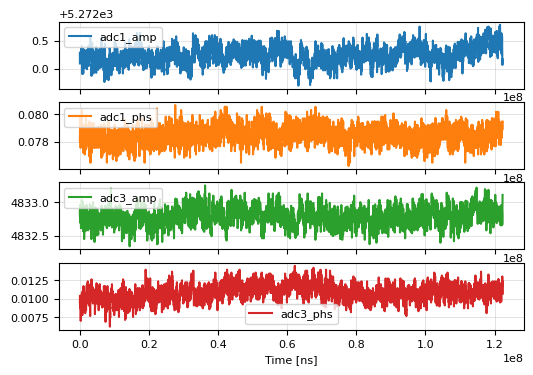

In [15]:
cols = [
    loop0_adc+'_amp', loop0_adc+'_phs',
    loop1_adc+'_amp', loop1_adc+'_phs'
]
df_mp_open = llrf.get_cic_wfm_df()
df_mp_open[cols].plot(subplots=True);

## Close loop test

In [16]:
llrf.init_loop('loop0', close_loop=True, amp_setp_adc=1e4, phs_setp_deg=10)
llrf.init_loop('loop1', close_loop=True, amp_setp_adc=1e4, phs_setp_deg=30)

In [17]:
llrf.close_loop('loop0')
llrf.close_loop('loop1')

In [18]:
llrf.get_rfmon()

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,20740,28906,34796.235194,79.392700
adc1,5960,3638,9999.303846,9.992065
adc2,2,-32458,3.355471,-89.148560
adc3,5959,10920,9997.626110,29.992676
adc4,0,36366,0.000000,180.000000
adc5,2,-65226,3.355471,-179.148560
adc6,2,36366,3.355471,99.882202
adc7,0,36366,0.000000,180.000000
drv0,6357,51907,18963.563457,-127.433167
drv1,6936,48560,20690.778061,-136.625977


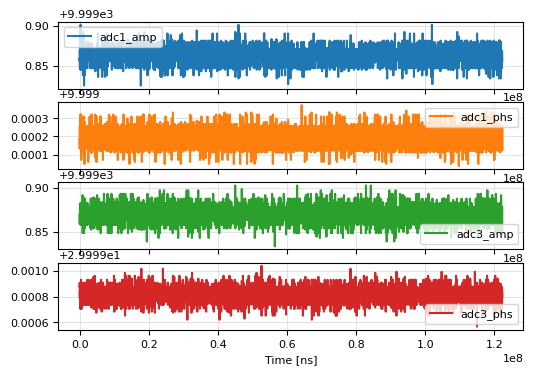

In [19]:
df_mp_close = llrf.get_cic_wfm_df()
df_mp_close[cols].plot(subplots=True);

In [20]:
for loop, loop_adc in zip([0, 1], [loop0_adc, loop1_adc]):
    amp_rms = df_mp_open[loop_adc+'_amp'].std() / df_mp_open[loop_adc+'_amp'].mean()
    phs_rms = df_mp_open[loop_adc+'_phs'].std()
    print(f'LOOP {loop}: Amp open  loop rms = {100 * amp_rms:.4f} %')
    print(f'LOOP {loop}: Phs open  loop rms = {100 * phs_rms:.4f} deg')
    amp_rms_close = df_mp_close[loop_adc+'_amp'].std() / df_mp_close[loop_adc+'_amp'].mean()
    phs_rms_close = df_mp_close[loop_adc+'_phs'].std()
    print(f'LOOP {loop}: Amp close loop rms = {100 * amp_rms_close:.4f} %')
    print(f'LOOP {loop}: Phs close loop rms = {100 * phs_rms_close:.4f} deg')

LOOP 0: Amp open  loop rms = 0.0031 %
LOOP 0: Phs open  loop rms = 0.0633 deg
LOOP 0: Amp close loop rms = 0.0001 %
LOOP 0: Phs close loop rms = 0.0051 deg
LOOP 1: Amp open  loop rms = 0.0029 %
LOOP 1: Phs open  loop rms = 0.1085 deg
LOOP 1: Amp close loop rms = 0.0001 %
LOOP 1: Phs close loop rms = 0.0059 deg


In [21]:
def plot_dual_loop_psd(df_psd_open, df_psd_close, type='amp',
                       loop0_adc=loop0_adc, loop1_adc=loop1_adc):
    fig, axes = plt.subplots(nrows=2, sharex=True)
    cols = [f'{loop0_adc}_{type}', f'{loop1_adc}_{type}']
    for col, ax in zip(cols, axes):
        df_psd_open[col].plot(logx=True, ax=ax, label=f'open {col}')
        df_psd_close[col].plot(logx=True, ax=ax, label=f'close {col}')
    for ax in axes:
        ax.legend();

In [22]:
df_psd_open = llrf.calc_psd_df(df_mp_open[cols])
df_psd_close = llrf.calc_psd_df(df_mp_close[cols])

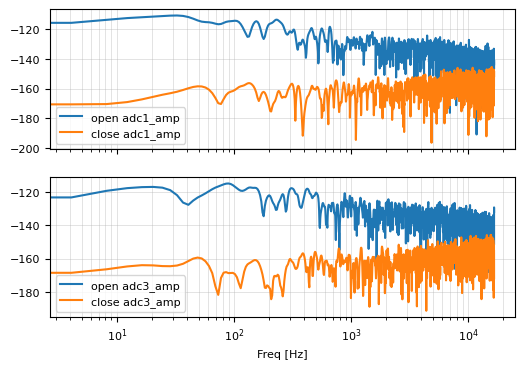

In [23]:
plot_dual_loop_psd(df_psd_open, df_psd_close, type='amp')

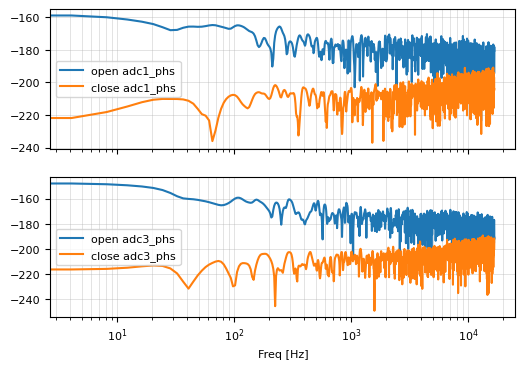

In [24]:
plot_dual_loop_psd(df_psd_open, df_psd_close, type='phs')

### Set CIC wave decimation factor to 1

For higher frequency bands, repeat the above steps.

Less averaging!

In [25]:
llrf.wave_samp_per = 1

In [26]:
llrf.open_loop('loop0')
llrf.open_loop('loop1')
llrf.init_loop('loop0', amp_setp_adc=1e4)
llrf.init_loop('loop1', amp_setp_adc=2e4)
llrf.get_rfmon()

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,20748,28946,34809.657079,7.950256e+01
adc1,3141,50011,5269.767346,1.373593e+02
adc2,2,-65226,3.355471,-1.791486e+02
adc3,5762,60670,9667.112208,1.666351e+02
adc4,2,-49138,3.355471,-1.349615e+02
adc5,2,-65226,3.355471,-1.791486e+02
adc6,0,36366,0.000000,1.800000e+02
adc7,2,36366,3.355471,9.988220e+01
drv0,3353,-32768,10002.332589,3.126015e-13
drv1,6706,-32768,20004.665179,3.126015e-13


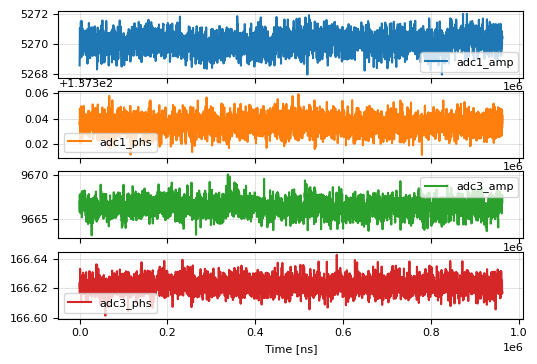

In [27]:
df_mp_open = llrf.get_cic_wfm_df()
df_mp_open[cols].plot(subplots=True);

## Close loop test

In [29]:
llrf.init_loop('loop0', close_loop=True, amp_setp_adc=1e4, phs_setp_deg=10)
llrf.init_loop('loop1', close_loop=True, amp_setp_adc=1e4, phs_setp_deg=30)

In [30]:
llrf.close_loop('loop0')
llrf.close_loop('loop1')

In [31]:
llrf.get_rfmon()

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,20738,28921,34792.879723,79.433899
adc1,5960,3638,9999.303846,9.992065
adc2,2,-32458,3.355471,-89.148560
adc3,5959,10920,9997.626110,29.992676
adc4,2,-49138,3.355471,-134.961548
adc5,2,-32458,3.355471,-89.148560
adc6,0,-32458,0.000000,0.000000
adc7,2,36366,3.355471,99.882202
drv0,6357,51903,18963.563457,-127.444153
drv1,6934,48560,20684.811862,-136.625977


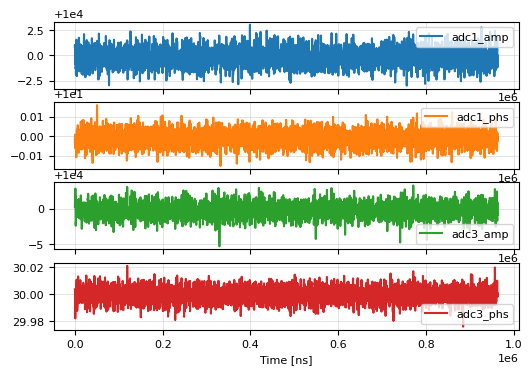

In [32]:
df_mp_close = llrf.get_cic_wfm_df()
df_mp_close[cols].plot(subplots=True);

In [33]:
for loop, loop_adc in zip([0, 1], [loop0_adc, loop1_adc]):
    amp_rms = df_mp_open[loop_adc+'_amp'].std() / df_mp_open[loop_adc+'_amp'].mean()
    phs_rms = df_mp_open[loop_adc+'_phs'].std()
    print(f'LOOP {loop}: Amp open  loop rms = {100 * amp_rms:.4f} %')
    print(f'LOOP {loop}: Phs open  loop rms = {100 * phs_rms:.4f} deg')
    amp_rms_close = df_mp_close[loop_adc+'_amp'].std() / df_mp_close[loop_adc+'_amp'].mean()
    phs_rms_close = df_mp_close[loop_adc+'_phs'].std()
    print(f'LOOP {loop}: Amp close loop rms = {100 * amp_rms_close:.4f} %')
    print(f'LOOP {loop}: Phs close loop rms = {100 * phs_rms_close:.4f} deg')

LOOP 0: Amp open  loop rms = 0.0117 %
LOOP 0: Phs open  loop rms = 0.6300 deg
LOOP 0: Amp close loop rms = 0.0088 %
LOOP 0: Phs close loop rms = 0.3888 deg
LOOP 1: Amp open  loop rms = 0.0092 %
LOOP 1: Phs open  loop rms = 0.4847 deg
LOOP 1: Amp close loop rms = 0.0102 %
LOOP 1: Phs close loop rms = 0.5181 deg


In [34]:
df_psd_open = llrf.calc_psd_df(df_mp_open[cols])
df_psd_close = llrf.calc_psd_df(df_mp_close[cols])

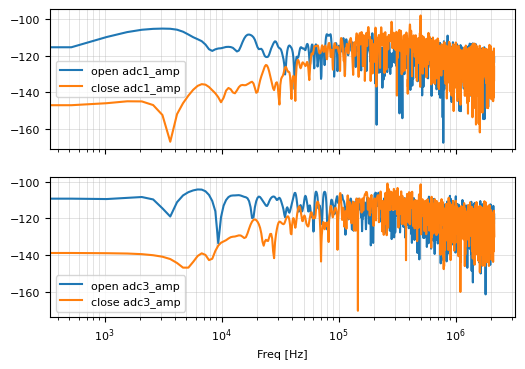

In [35]:
plot_dual_loop_psd(df_psd_open, df_psd_close, type='amp')

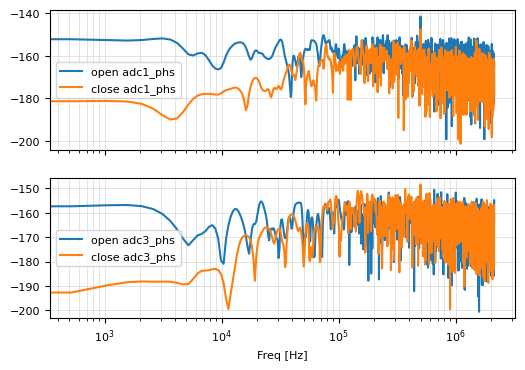

In [36]:
plot_dual_loop_psd(df_psd_open, df_psd_close, type='phs')

In [37]:
llrf.open_loop('loop0')
llrf.open_loop('loop1')